# Итоговый проект PRO: Углубленный NLP анализ отзывов «Додо Пицца»
**Стек:** pandas, nltk, pymorphy3, scikit-learn, matplotlib, seaborn, wordcloud.
Включает лемматизацию текста, визуализацию облаков слов и построение матрицы ошибок.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
import pymorphy3
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

morph = pymorphy3.MorphAnalyzer()

In [2]:
df = pd.read_excel('reviews.xlsx')
df['sentiment'] = df['Оценка'].apply(lambda x: 1 if x >= 4 else 0)
print(f"Успешно загружено отзывов: {len(df)}")
display(df.head(3))

Успешно загружено отзывов: 35


,ID,Текст отзыва,Оценка,Источник,sentiment
0,1,"Привезли ледяную пиццу, курьер опоздал на час....",1,Yandex,0
1,2,Обожаю их сырные бортики! Всегда заказываем по...,5,IRecommend,1
2,3,Ну такое... Раньше начинки было явно больше. С...,3,Otzovik,0


In [3]:
stop_words = set(stopwords.words('russian'))
stop_words.update(['это', 'очень', 'просто', 'всё', 'весь', 'свой', 'который', 'додо'])

def deep_clean_and_lemmatize(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яёa-z\s]', '', text)
    tokens = word_tokenize(text)
    lemmatized_tokens = [morph.parse(w)[0].normal_form for w in tokens]
    filtered_tokens = [w for w in lemmatized_tokens if w not in stop_words and len(w) > 2]
    return ' '.join(filtered_tokens)

df = df.dropna(subset=['Текст отзыва'])
df['clean_text'] = df['Текст отзыва'].apply(deep_clean_and_lemmatize)
display(df[['Текст отзыва', 'clean_text']].head())

,Текст отзыва,clean_text
0,"Привезли ледяную пиццу, курьер опоздал на час....",привезти ледяной пицца курьер опоздать час под...
1,Обожаю их сырные бортики! Всегда заказываем по...,обожать сырный бортик заказывать пятница семья...
2,Ну такое... Раньше начинки было явно больше. С...,ранний начинка явно большой тесто жевать
3,"Доставили за 25 минут! Пицца аж горячая была, ...",доставить минута пицца горячий обжечься красав...
4,"Деньги списали, заказ отменили из-за техническ...",деньга списать заказ отменить изз технический ...


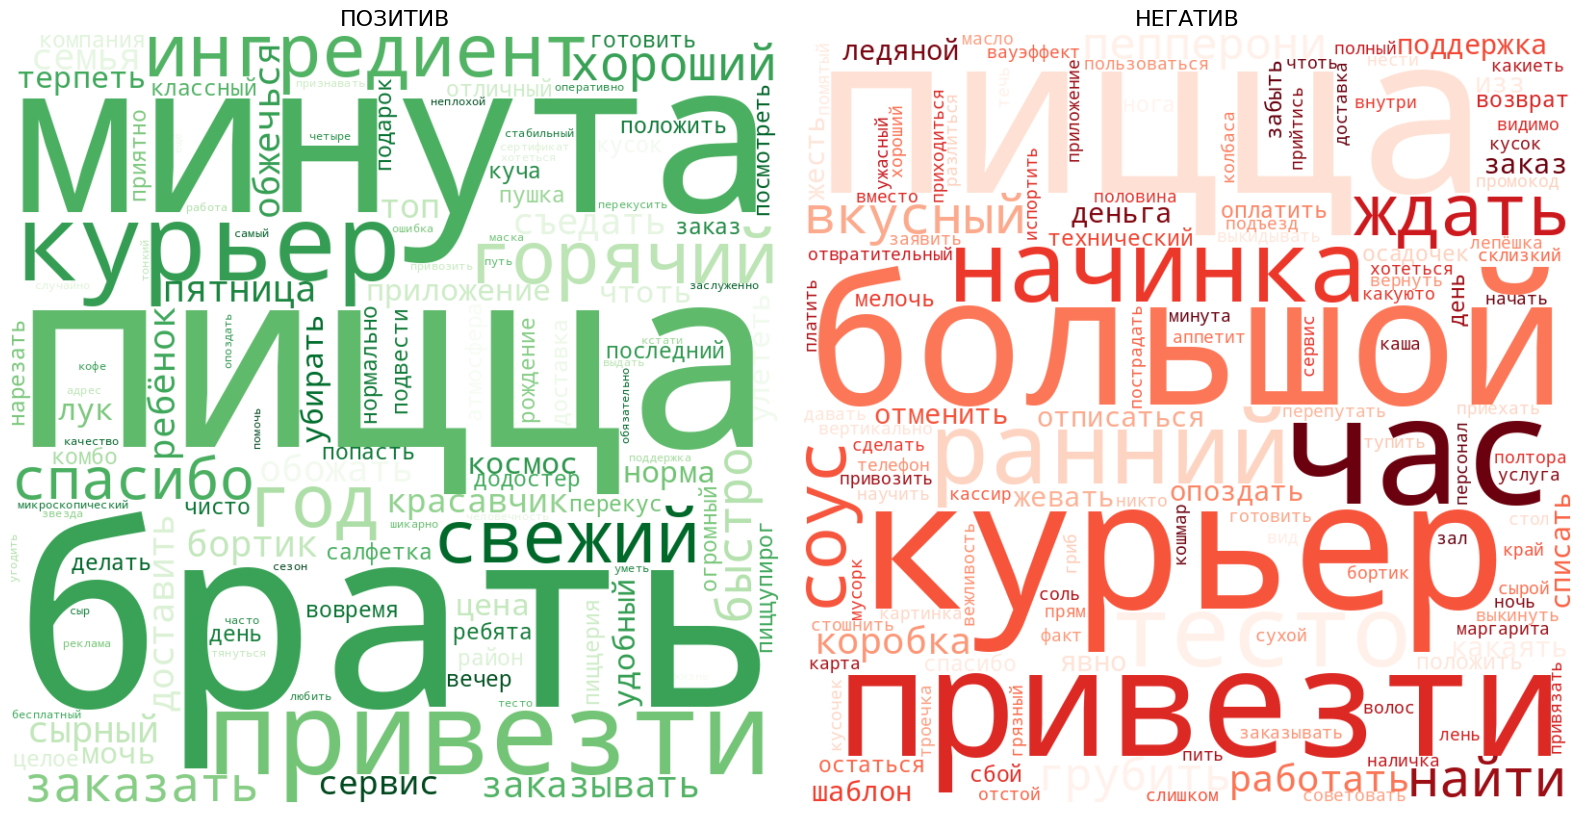

In [4]:
pos_text = ' '.join(df[df['sentiment'] == 1]['clean_text'])
neg_text = ' '.join(df[df['sentiment'] == 0]['clean_text'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

wordcloud_pos = WordCloud(width=800, height=800, background_color='white', colormap='Greens', min_font_size=10).generate(pos_text)
ax1.imshow(wordcloud_pos, interpolation='bilinear')
ax1.set_title('ПОЗИТИВ', fontsize=16)
ax1.axis('off')

wordcloud_neg = WordCloud(width=800, height=800, background_color='white', colormap='Reds', min_font_size=10).generate(neg_text)
ax2.imshow(wordcloud_neg, interpolation='bilinear')
ax2.set_title('НЕГАТИВ', fontsize=16)
ax2.axis('off')

plt.tight_layout()
plt.show()

Accuracy: 0.86

              precision    recall  f1-score   support

     Негатив       1.00      0.75      0.86         4
     Позитив       0.75      1.00      0.86         3

    accuracy                           0.86         7
   macro avg       0.88      0.88      0.86         7
weighted avg       0.89      0.86      0.86         7



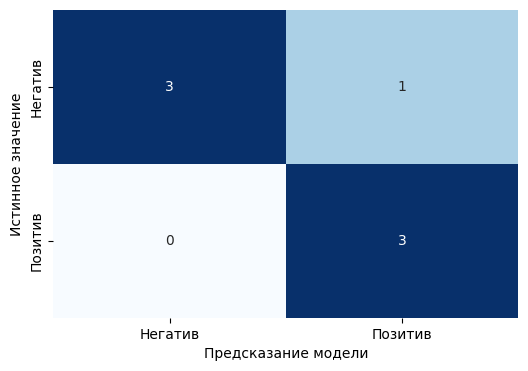

In [5]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('clf', LogisticRegression(random_state=42, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}\n")
print(classification_report(y_test, predictions, target_names=['Негатив', 'Позитив'], zero_division=0))

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Негатив', 'Позитив'], yticklabels=['Негатив', 'Позитив'])
plt.xlabel('Предсказание модели')
plt.ylabel('Истинное значение')
plt.show()